In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Total messages sent: 6860
Total messages processed by device 3: 6860
Difference between sent and processed by device 3: 0
Total messages processed by device 5: 6860
Difference between sent and processed by device 5: 0
Total messages processed by device 6: 6860
Difference between sent and processed by device 6: 0
Total messages processed by device 7: 6860
Difference between sent and processed by device 7: 0


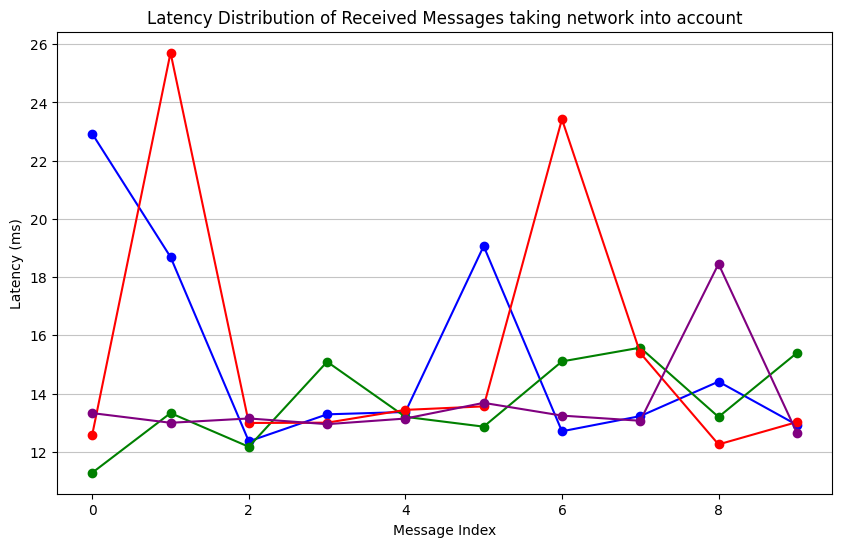

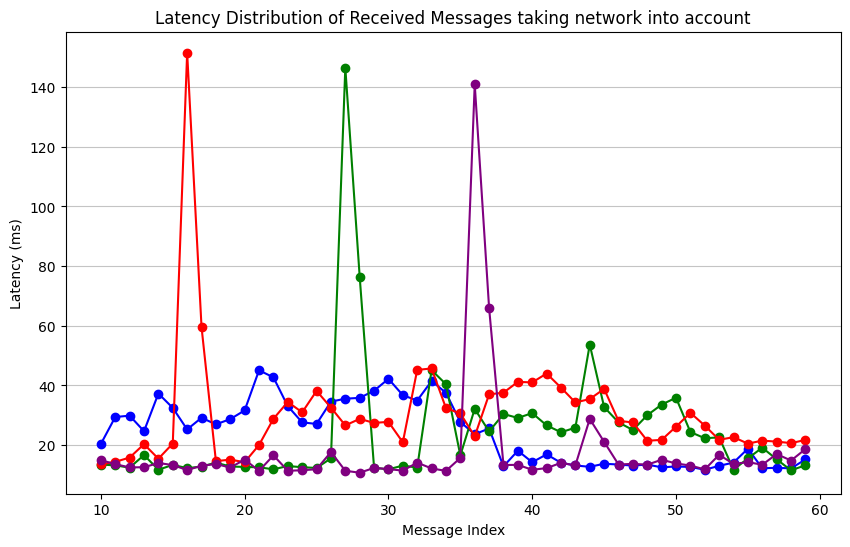

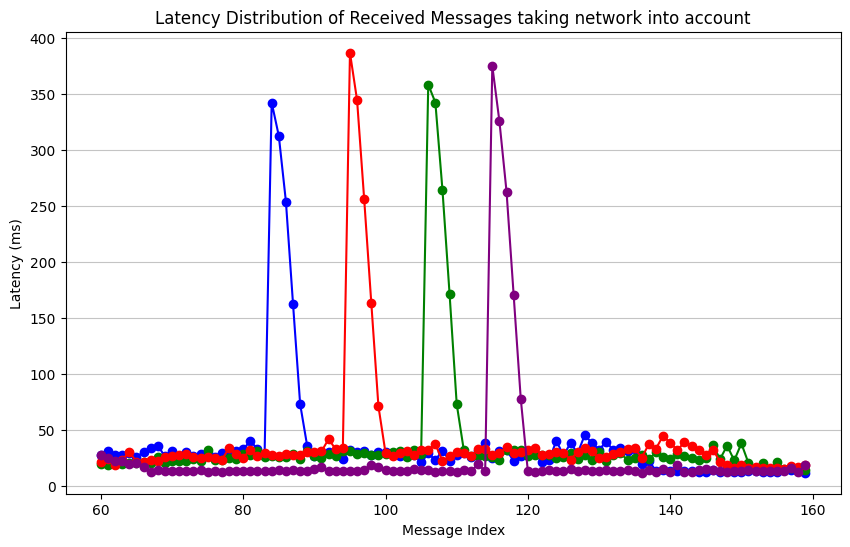

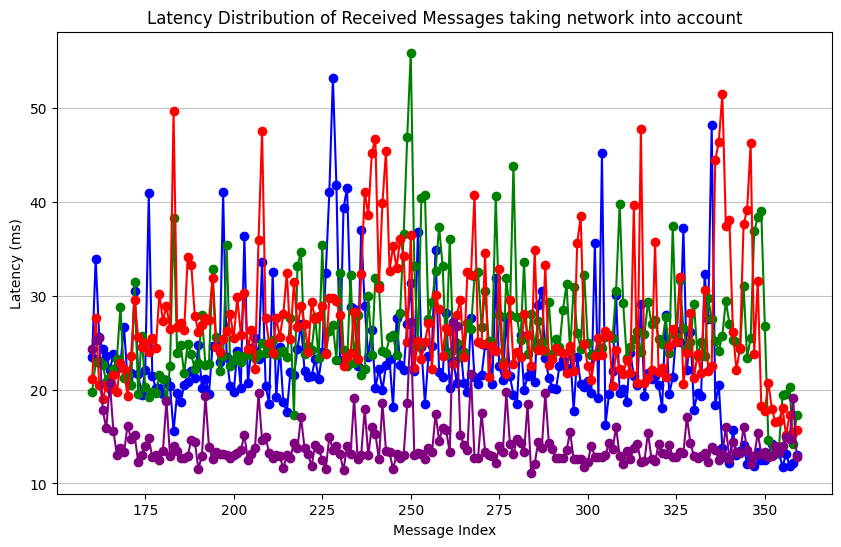

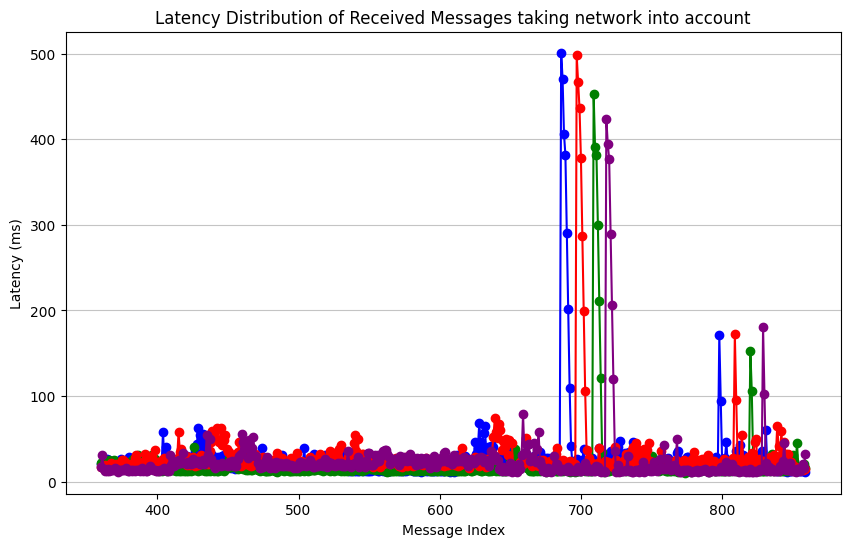

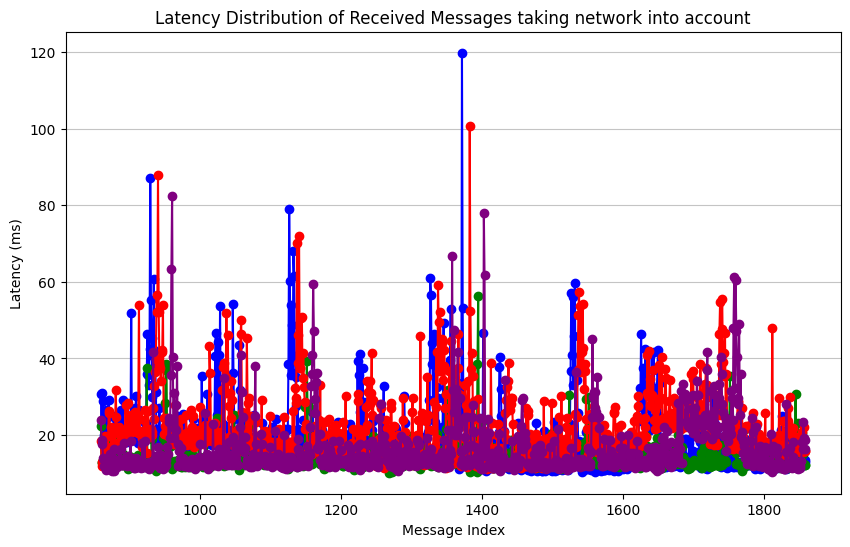

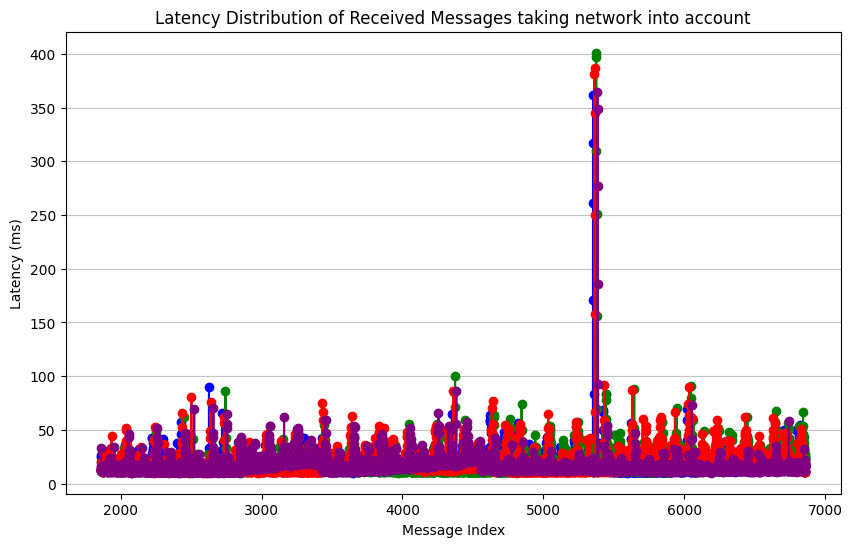

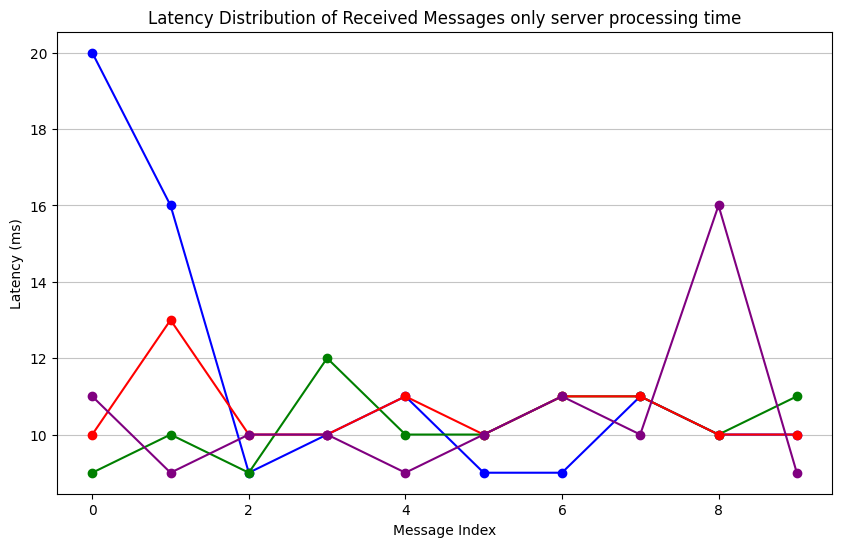

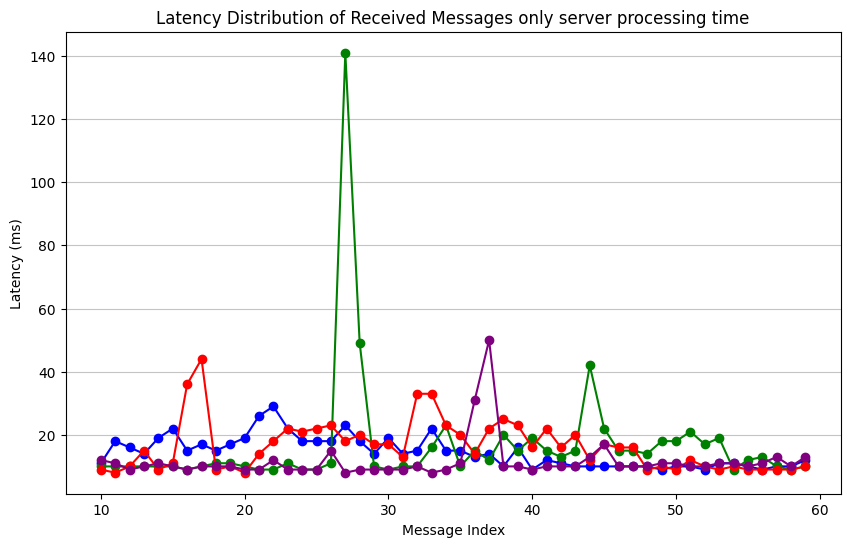

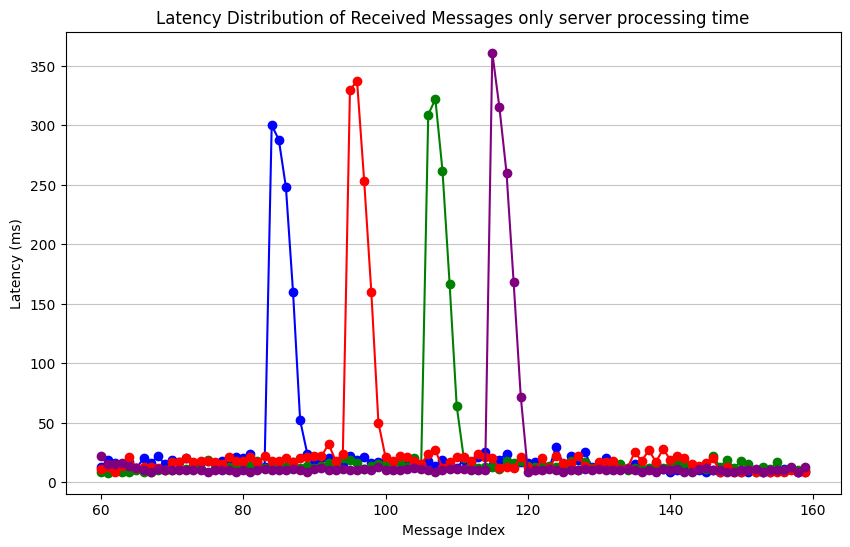

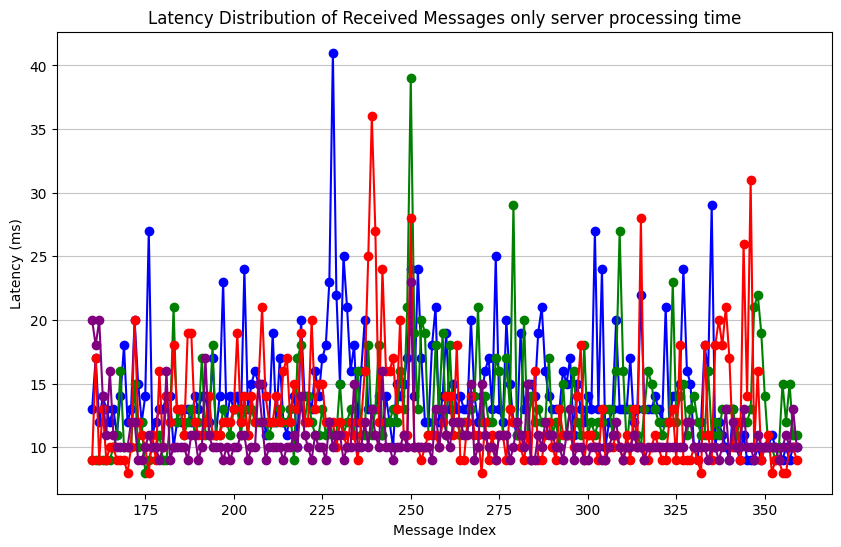

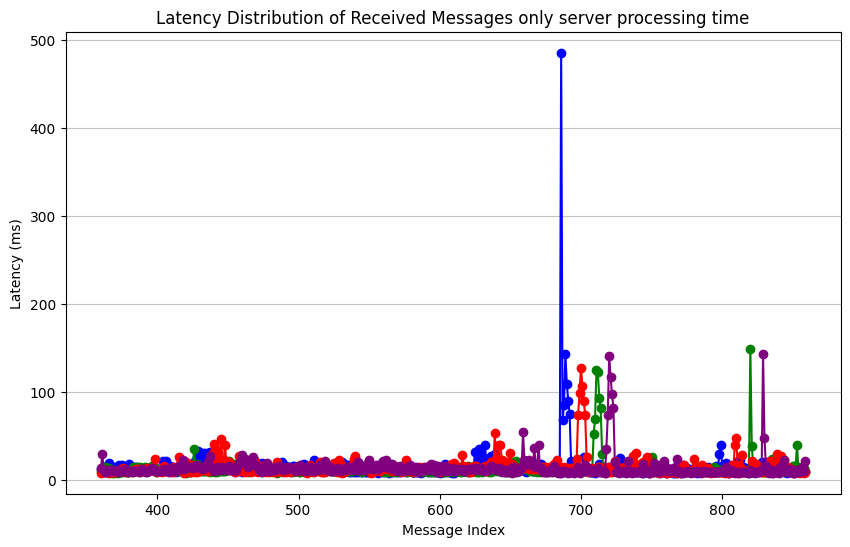

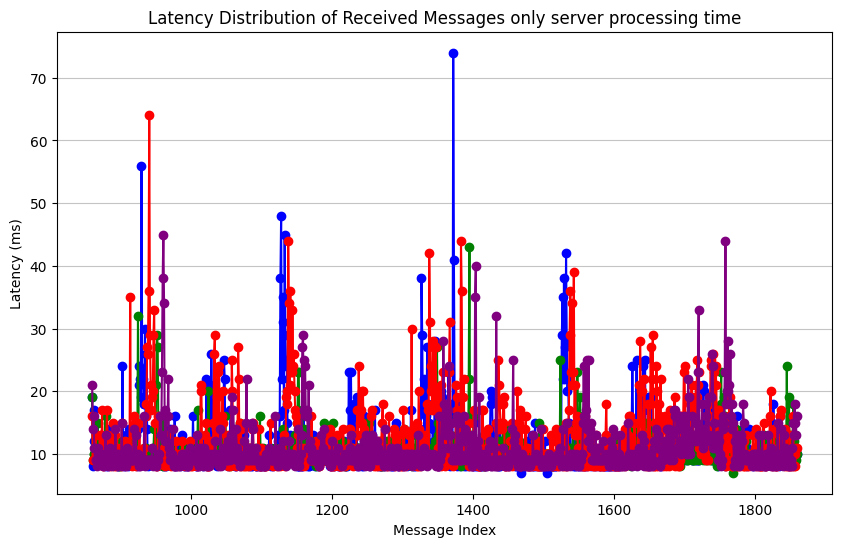

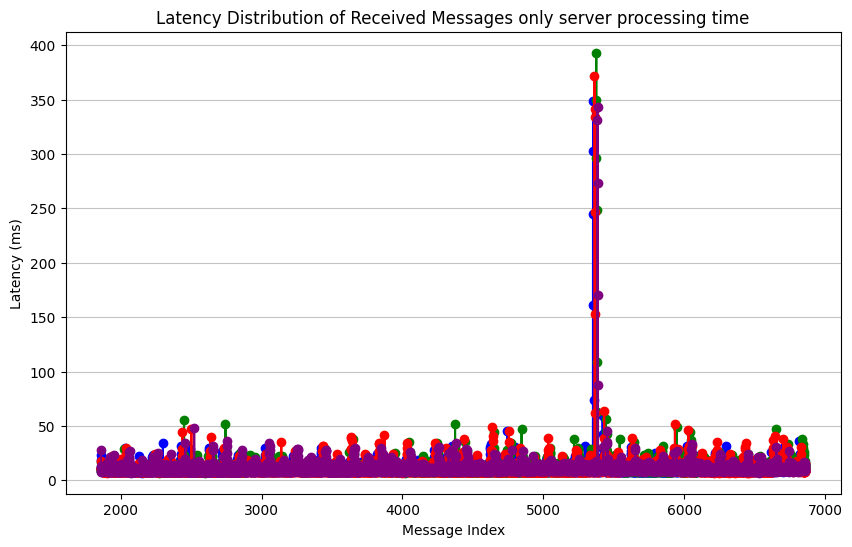

In [2]:
df_3 = pd.read_csv('resultados_latencia-rbpi3.csv')
# df_4 = pd.read_csv('resultados_latencia-rbpi4.csv')
df_5 = pd.read_csv('resultados_latencia-rbpi5.csv')
df_6 = pd.read_csv('resultados_latencia-rbpi6.csv')
df_7 = pd.read_csv('resultados_latencia-rbpi7.csv')


df_3.reset_index(inplace=True)
# df_4.reset_index(inplace=True)
df_5.reset_index(inplace=True)
df_6.reset_index(inplace=True)
df_7.reset_index(inplace=True)



pruebas = [10, 50, 100, 200, 500, 1000, 5000]
lista = []
contador = 0
for prueba in pruebas:
    for i in range(0, prueba):
        lista.append(prueba)
        contador += 1




df_3['grupo'] = lista   
# df_4['grupo'] = lista   
df_5['grupo'] = lista   
df_6['grupo'] = lista   
df_7['grupo'] = lista

print("Total messages sent:", sum(pruebas))
print("Total messages processed by device 3:", df_3.shape[0])
print("Difference between sent and processed by device 3:", sum(pruebas) - df_3.shape[0])
# print("Total messages processed by device 4:", df_4.shape[0])
# print("Difference between sent and processed by device 4:", sum(pruebas) - df_4.shape[0])
print("Total messages processed by device 5:", df_5.shape[0])
print("Difference between sent and processed by device 5:", sum(pruebas) - df_5.shape[0])
print("Total messages processed by device 6:", df_6.shape[0])
print("Difference between sent and processed by device 6:", sum(pruebas) - df_6.shape[0])
print("Total messages processed by device 7:", df_7.shape[0])
print("Difference between sent and processed by device 7:", sum(pruebas) - df_7.shape[0])


df_3["server_latency"] = df_3["from_server_ts"] - df_3["time"]
df_3["general_latency"] = df_3["timestamp_recepcion"]/1000000 - df_3["sending_timestamp"]/1000000
df_5["server_latency"] = df_5["from_server_ts"] - df_5["time"]
df_5["general_latency"] = df_5["timestamp_recepcion"]/1000000 - df_5["sending_timestamp"]/1000000
df_6["server_latency"] = df_6["from_server_ts"] - df_6["time"]
df_6["general_latency"] = df_6["timestamp_recepcion"]/1000000 - df_6["sending_timestamp"]/1000000
df_7["server_latency"] = df_7["from_server_ts"] - df_7["time"]
df_7["general_latency"] = df_7["timestamp_recepcion"]/1000000 - df_7["sending_timestamp"]/1000000



lista_pruebas_csv = []


     
for prueba in pruebas:
    df2_3 = df_3[df_3['grupo'] == prueba]
    df2_5 = df_5[df_5['grupo'] == prueba]
    df2_6 = df_6[df_6['grupo'] == prueba]
    df2_7 = df_7[df_7['grupo'] == prueba]
    
    mean_latency_3_general = df2_3['general_latency'].mean()
    mean_latency_5_general = df2_5['general_latency'].mean()
    mean_latency_6_general = df2_6['general_latency'].mean()
    mean_latency_7_general = df2_7['general_latency'].mean()
    
    max_latency_3_general = df2_3['general_latency'].max()
    max_latency_5_general = df2_5['general_latency'].max()
    max_latency_6_general = df2_6['general_latency'].max()
    max_latency_7_general = df2_7['general_latency'].max()
    
    mean_latency_3_server = df2_3['server_latency'].mean()
    mean_latency_5_server = df2_5['server_latency'].mean()
    mean_latency_6_server = df2_6['server_latency'].mean()
    mean_latency_7_server = df2_7['server_latency'].mean()
    
    max_latency_3_server = df2_3['server_latency'].max()
    max_latency_5_server = df2_5['server_latency'].max()
    max_latency_6_server = df2_6['server_latency'].max()
    max_latency_7_server = df2_7['server_latency'].max()
    
    lista_pruebas_csv.append({
        'prueba': prueba,
        'mean_latency_3_general': mean_latency_3_general,
        'mean_latency_5_general': mean_latency_5_general,
        'mean_latency_6_general': mean_latency_6_general,
        'mean_latency_7_general': mean_latency_7_general,
        'max_latency_3_general': max_latency_3_general,
        'max_latency_5_general': max_latency_5_general,
        'max_latency_6_general': max_latency_6_general,
        'max_latency_7_general': max_latency_7_general,
        'mean_latency_3_server': mean_latency_3_server,
        'mean_latency_5_server': mean_latency_5_server,
        'mean_latency_6_server': mean_latency_6_server,
        'mean_latency_7_server': mean_latency_7_server,
        'max_latency_3_server': max_latency_3_server,
        'max_latency_5_server': max_latency_5_server,
        'max_latency_6_server': max_latency_6_server,
        'max_latency_7_server': max_latency_7_server
    })
    
    plt.figure(figsize=(10, 6))
    plt.plot(df2_3['index'], df2_3['general_latency'], marker='o', linestyle='-', color='blue')
    plt.plot(df2_5['index'], df2_5['general_latency'], marker='o', linestyle='-', color='green')
    plt.plot(df2_6['index'], df2_6['general_latency'], marker='o', linestyle='-', color='red')
    plt.plot(df2_7['index'], df2_7['general_latency'], marker='o', linestyle='-', color='purple')
    # plt.hist(df[df2_3]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages taking network into account')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_{prueba}.png')
    
lista_pruebas_df = pd.DataFrame(lista_pruebas_csv)
lista_pruebas_df.to_csv('latency_summary.csv', index=False)

for prueba in pruebas:
    df2_3 = df_3[df_3['grupo'] == prueba]
    df2_5 = df_5[df_5['grupo'] == prueba]
    df2_6 = df_6[df_6['grupo'] == prueba]
    df2_7 = df_7[df_7['grupo'] == prueba]
    
    plt.figure(figsize=(10, 6))
    plt.plot(df2_3['index'], df2_3['server_latency'], marker='o', linestyle='-', color='blue')
    plt.plot(df2_5['index'], df2_5['server_latency'], marker='o', linestyle='-', color='green')
    plt.plot(df2_6['index'], df2_6['server_latency'], marker='o', linestyle='-', color='red')
    plt.plot(df2_7['index'], df2_7['server_latency'], marker='o', linestyle='-', color='purple')
    # plt.hist(df[df2_3]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages only server processing time')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_s_s_{prueba}.png')

# print("Total messages processed:", contador)
# print("Total messages dropped:", sum(pruebas) - contador)


